Importing the libraries

In [ ]:
import numpy as np
import keras
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing.image import img_to_array
import matplotlib.pyplot as plt
%matplotlib inline
import random
import cv2
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Sorting the path of data into veriable
train_dir = '/content/drive/MyDrive/RiceLeaf/train'  #Location of training images
validation_dir = '/content/drive/MyDrive/RiceLeaf/val'  # Location of test images
test_dir ='/content/drive/MyDrive/RiceLeaf/test' # Location of test images

In [ ]:
# Generating batches of image data
train_datagen = ImageDataGenerator(
    rescale= (1./255),
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=(1./255))

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(180,180),
    batch_size=16,
    color_mode='rgb',
    class_mode='categorical')

val_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(180,180),
    batch_size=16,
    color_mode='rgb',
    class_mode='categorical')

Found 119 images belonging to 3 classes.
Found 119 images belonging to 3 classes.


In [ ]:
# plotting train images with their labels
def plots(ims, figsize=(20,25), rows=4, interp = False, title = None):
    f = plt.figure(figsize=figsize)
    cols = len(ims) // rows if len(ims) % 2 ==0 else len(ims) // rows+1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('off')
        sp.set_title(class_names[title[i].tolist().index(1)],fontsize=16)
        plt.imshow(ims[i])


# Make list of classes
class_names = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

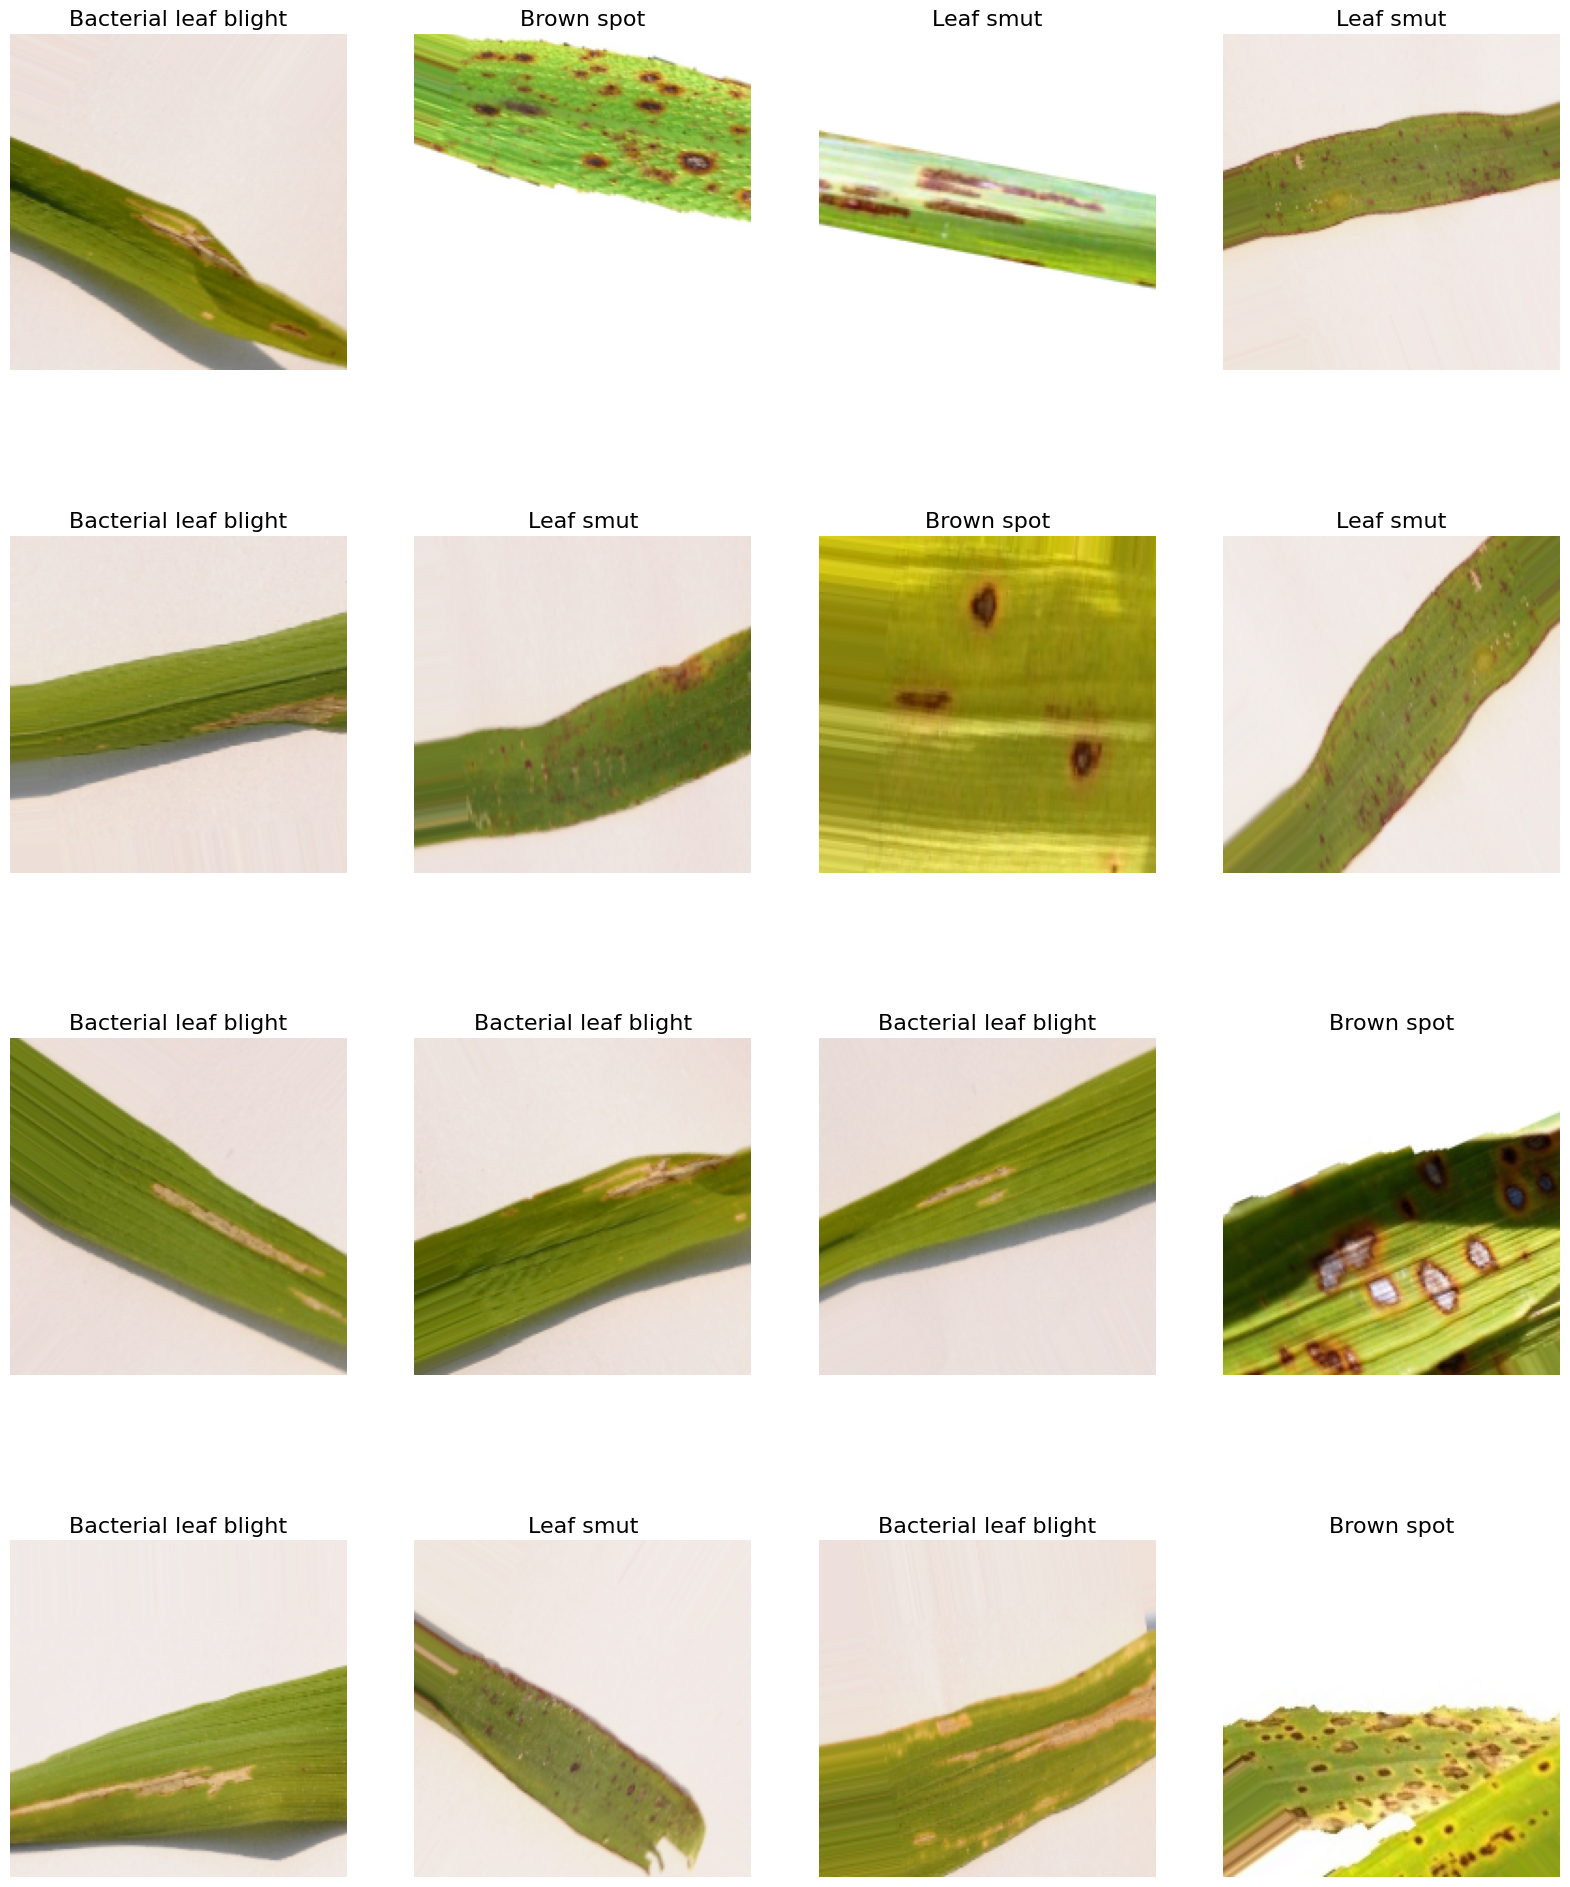

In [ ]:
imgs, labels = next(train_generator)
plots(imgs, title = labels)

In [ ]:
from tensorflow.keras.layers import Activation
from keras import models, layers
model = models.Sequential()
model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',input_shape=(180,180,3)))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Conv2D(filters=64,kernel_size=(3,3),activation= 'relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Conv2D(filters=128,kernel_size=(3,3),activation= 'relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Conv2D(filters=256,kernel_size=(3,3),activation= 'relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Dropout(rate=0.5))
model.add(layers.Flatten())
model.add(layers.Dense(3, activation ='softmax'))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │        62,211 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 450,627 (1.72 MB)

 Trainable params: 450,627 (1.72 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import optimizers
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# Fitting the data

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 72s 9s/step - accuracy: 0.2713 - loss: 1.1287 - val_accuracy: 0.3361 - val_loss: 1.0930
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.3541 - loss: 1.0950 - val_accuracy: 0.4706 - val_loss: 1.0686
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4595 - loss: 1.0639 - val_accuracy: 0.5210 - val_loss: 0.9781
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.3712 - loss: 1.1100 - val_accuracy: 0.7311 - val_loss: 0.9774
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.4938 - loss: 1.0363 - val_accuracy: 0.5630 - val_loss: 0.8673
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4980 - loss: 0.9569 - val_accuracy: 0.6555 - val_loss: 0.9313
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5929 - loss: 0.9297 - val_accuracy: 0.6891 - val_loss: 0.7337
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6037 - loss: 0.8476 - val_accuracy: 0.7311 - val_loss: 0.7171
Epoch 9/

AFTER TRAINING
>Validation accuracy 83.19%
>Training accuracy 84.38%

In [ ]:
model.save("model.h5")

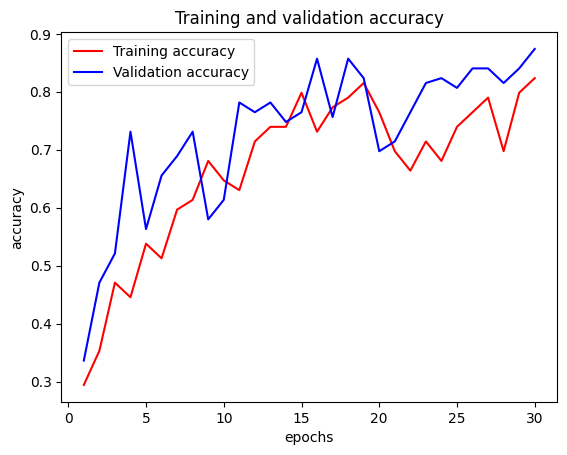

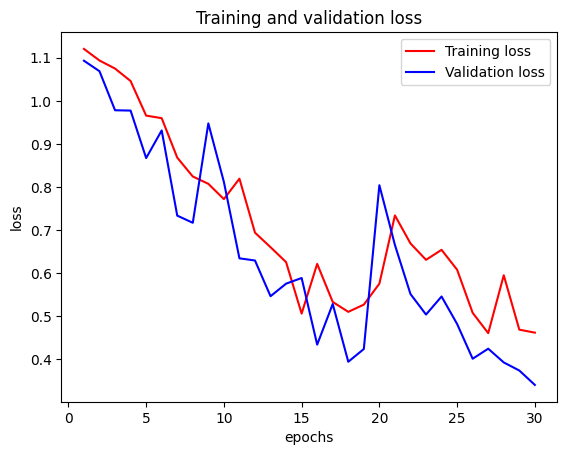

In [ ]:
# Plotting the traning loss and validation loss
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "r", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

EVALUATION AND TESTING MODEL

In [ ]:
test_datagen=ImageDataGenerator(rescale=(1./255))

test_generator=test_datagen.flow_from_directory(
    test_dir,
    target_size=(180,180),
    batch_size=16,
    color_mode='rgb',
    class_mode='categorical')

Found 119 images belonging to 3 classes.


In [ ]:
model.evaluate(test_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.8849 - loss: 0.3599


[0.341007798910141, 0.8739495873451233]

VISUALISE THE PREDICTION OF MODEL

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


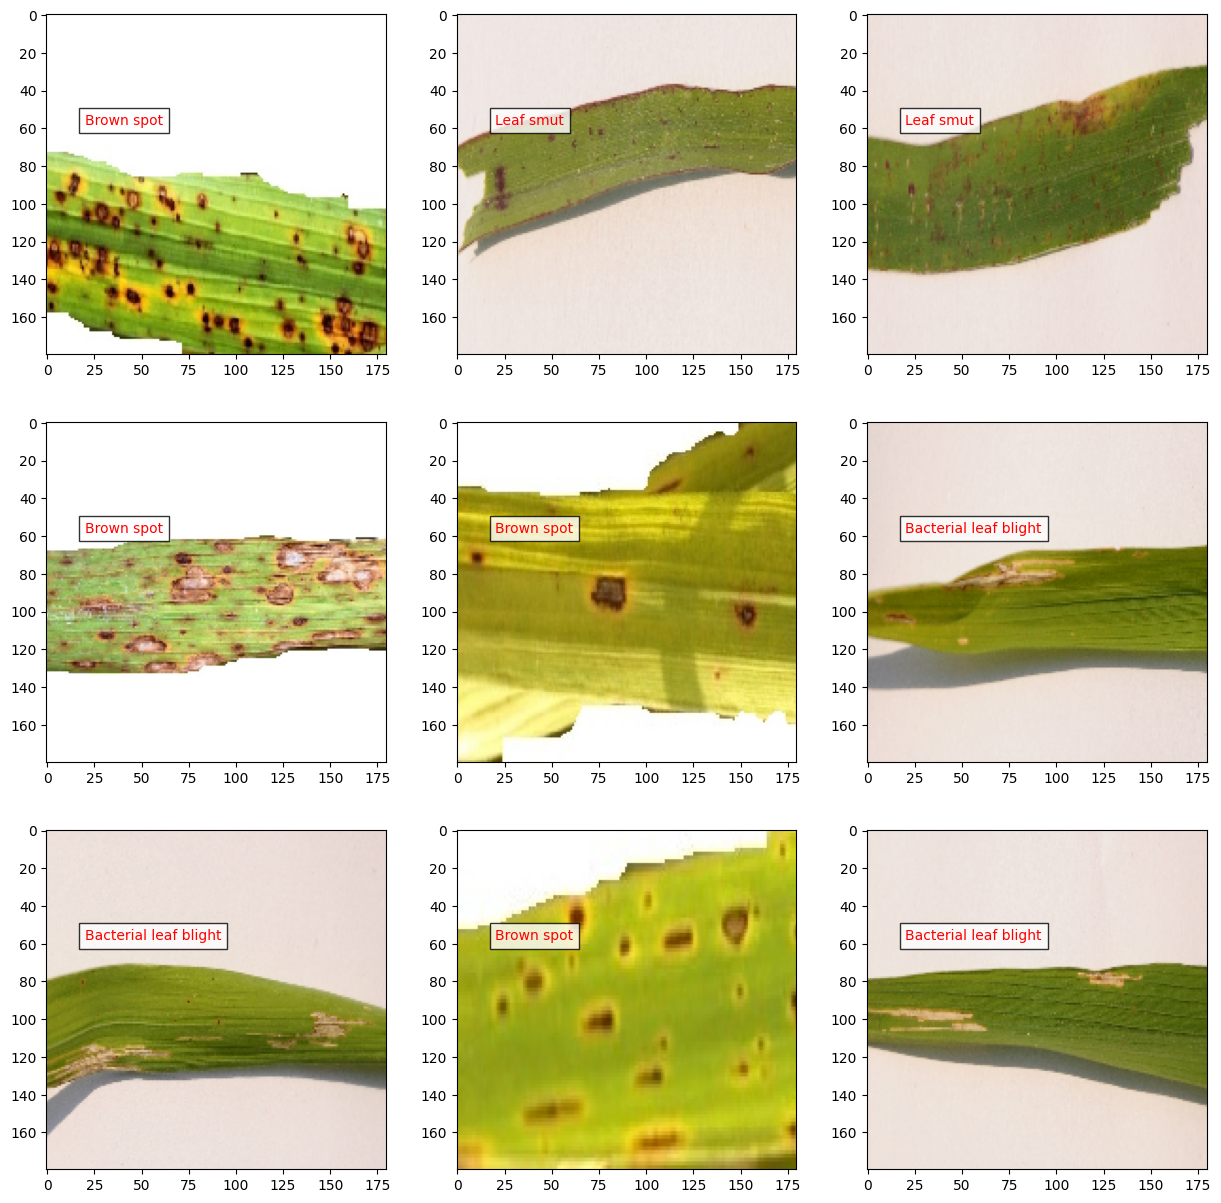

In [ ]:
#Visualise the prediction of the model
imgs,labels=next(test_generator)
fig=plt.figure(figsize=(15,15))
columns=3
rows=3
for i in range(columns*rows):
  fig.add_subplot(rows,columns,i+1)
  img_t=np.expand_dims(imgs[i],axis=0)
  prediction=model.predict(img_t)
  idx=prediction[0].tolist().index(max(prediction[0]))
  plt.text(20,58,class_names[idx],color='red',fontsize=10,bbox=dict(facecolor='white',alpha=0.8))
  plt.imshow(imgs[i])

Conclusion

A Rice Leaf Disease Detection system was developed using Deep Learning techniques. The main goal of the project was to automatically identify diseases in rice leaves using image classification. A Convolutional Neural Network (CNN) model was used to analyze the images of rice leaves and classify them into different categories such as healthy and diseased.